# Generative Modeling from First Principles
### ELBO, Adversarial Games, and Reverse Diffusion

This notebook is a rewrite of the usual "VAE, GAN, and Diffusion from scratch" tour with three rules:

1. **Every figure demonstrates a measurable claim.** No cherry-picked sample strips. If we assert "mode collapse", we *measure* it; if we assert "the closed-form forward diffusion is correct", we *verify* it numerically.
2. **Derive the math, then implement it.** The ELBO, the optimal GAN discriminator, the score/noise equivalence, and the DDPM forward/reverse equations are derived, not asserted.
3. **Stay beginner-accessible.** Intuition is kept, but it is always cashed out into an equation or an experiment.

**Runtime.** All *image* models are small MLPs on MNIST resized to **8×8** (`QUICK=True`, laptop CPU smoke test) or **32×32** (`QUICK=False`, readable digits). Data comes from `torchvision` MNIST when available, else `sklearn`'s `load_digits` (offline, native 8×8).

**Google Colab.** Open this notebook from GitHub (see repo README), choose **Runtime → Change runtime type → GPU**, then **Run all**. On a fresh runtime you may need `!pip install -q scikit-learn scipy` once.

***
### Structure
- **Part 0** — One unifying framework: what object are we actually learning?
- **Part 1** — VAE: intractable MLE → ELBO derivation → latent-space diagnostics → the *exact* reason L2 decoders blur → **VQ-VAE** (flat + conv) as a discrete-latent fix (GANs in Part 2).
- **Part 2** — GAN: minimax → optimal discriminator → JS divergence → collapse & instability *measured*.
- **Part 3** — Denoising score matching: predicting noise ≈ learning $\nabla_x \log p(x)$.
- **Part 4** — DDPM: forward/reverse derived from first principles, verified, sampled (ancestral + DDIM).
- **Part 5** — Comparing objectives quantitatively (class-entropy + a Fréchet feature distance) + the modern diffusion family.
- **Appendix** — Common misconceptions, each linked to the cell that debunks it.

In [3]:
import math, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# QUICK=True  -> 8x8 digits + fewer steps (CPU smoke test, ~minutes)
# QUICK=False -> 32x32 digits (readable; fine on Colab GPU or patient CPU)
QUICK = False
IMG = 8 if QUICK else 32
print("device:", device, "| QUICK:", QUICK, "| IMG:", IMG, "| torch:", torch.__version__)

device: mps | QUICK: False | torch: 2.9.1


data: torchvision MNIST (resized to 32x32) | shape: (60000, 1, 32, 32) | classes: 10


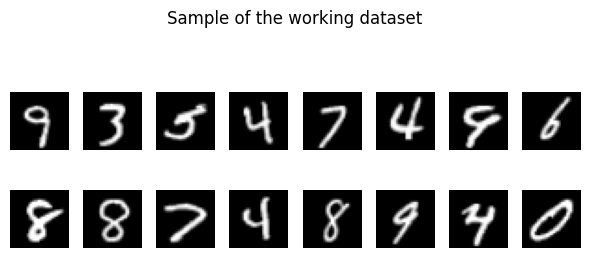

In [4]:
DIM = IMG * IMG  # IMG set in previous cell (8 if QUICK else 32)

def load_digit_images(img=IMG):
    """Return X in [0,1] shape (N,1,img,img), labels y, and a source string.

    Tries torchvision MNIST (downloads once). Falls back to sklearn load_digits,
    which ships with the library and needs no network.
    """
    try:
        from torchvision import datasets, transforms
        ds = datasets.MNIST(root="./data", train=True, download=True)
        X = ds.data.float().unsqueeze(1) / 255.0          # (60000,1,28,28)
        y = ds.targets.clone()
        source = "torchvision MNIST (resized to %dx%d)" % (img, img)
    except Exception:
        from sklearn.datasets import load_digits
        d = load_digits()
        X = torch.tensor(d.images, dtype=torch.float32).unsqueeze(1) / 16.0  # (1797,1,8,8)
        y = torch.tensor(d.target, dtype=torch.long)
        source = "sklearn load_digits (offline fallback)"
    if X.shape[-1] != img:
        X = F.interpolate(X, size=(img, img), mode="bilinear", align_corners=False)
    X = X.clamp(0, 1)
    return X, y, source

X_all, y_all, DATA_SOURCE = load_digit_images()
N_MAX = 6000 if QUICK else len(X_all)
perm = torch.randperm(len(X_all))[:N_MAX]
X_all, y_all = X_all[perm].to(device), y_all[perm].to(device)
print("data:", DATA_SOURCE, "| shape:", tuple(X_all.shape), "| classes:", int(y_all.max()) + 1)

def show_grid(imgs, nrow=8, title=None, figsize=(6, 3)):
    """imgs: (N,1,IMG,IMG) or (N,DIM) tensor in [0,1]."""
    imgs = imgs.detach().cpu().reshape(-1, IMG, IMG)
    n = imgs.shape[0]; ncol = nrow; nrows = math.ceil(n / ncol)
    fig, ax = plt.subplots(nrows, ncol, figsize=figsize)
    ax = np.array(ax).reshape(-1)
    for i in range(len(ax)):
        ax[i].axis("off")
        if i < n:
            ax[i].imshow(imgs[i], cmap="gray", vmin=0, vmax=1)
    if title: fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_grid(X_all[:16], nrow=8, title="Sample of the working dataset")

## Part 0 — One unifying framework

A common opening line is *"all generative models map noise to data."* That is true but lossy: it flattens distinctions that matter the moment you try to train or evaluate these models.

The object we actually want is a distribution over data,

$$p_\theta(x) \approx p_{\text{data}}(x),$$

and the three families differ in **what they commit to modeling**:

| Model | What it learns | Likelihood $p_\theta(x)$? | Sampling |
|---|---|---|---|
| **VAE** | a latent-variable *likelihood* model $p_\theta(x\mid z)p(z)$ | tractable **lower bound** (ELBO) | ancestral: $z\sim p(z),\; x\sim p_\theta(x\mid z)$ |
| **GAN** | an *implicit* sampler $G_\theta(z)$ | **undefined** (no density) | one forward pass $x=G_\theta(z)$ |
| **DDPM** | the transitions of a *reverse stochastic process* | tractable **lower bound** (also an ELBO!) | iterative denoising, $T$ steps |

Why the distinction matters in practice:

- The VAE decoder defines an explicit likelihood $p_\theta(x\mid z)$, so its failure modes are *likelihood* failure modes (e.g. a Gaussian likelihood forces the decoder toward a conditional **mean** — Part 1.4).
- A GAN defines **no** density. You cannot ask "what is $p_\theta(x)$?"; you can only sample. This is exactly why we must evaluate it with sample-based metrics (Part 2.2, Part 5).
- A DDPM commits to a *Markov chain*. Its training target and its samplers (ancestral vs DDIM, Part 4) are consequences of that chain, not of a single "noise→image" map.

Interestingly, VAE and DDPM both optimize an ELBO — a DDPM is, formally, a deep hierarchical VAE with a *fixed* (non-learned) encoder (the forward noising process). We'll see the shared skeleton by Part 4.

## Part 1 — VAE

### 1.1 Why maximum likelihood becomes intractable

We posit a latent-variable model: a prior $p(z)=\mathcal N(0,I)$ and a decoder $p_\theta(x\mid z)$. The marginal likelihood of a datapoint is

$$p_\theta(x)=\int p_\theta(x\mid z)\,p(z)\,dz .$$

To do maximum likelihood we would maximize $\sum_x \log p_\theta(x)$, but the integral is intractable:

- $z$ is continuous and high-dimensional, so there is no closed form for a neural $p_\theta(x\mid z)$.
- A naive Monte Carlo estimate $p_\theta(x)\approx \frac1S\sum_s p_\theta(x\mid z^{(s)}),\ z^{(s)}\sim p(z)$ has catastrophic variance: for almost every prior sample $z^{(s)}$, $p_\theta(x\mid z^{(s)})\approx 0$. The posterior $p_\theta(z\mid x)$ is concentrated on a tiny region of latent space that prior samples essentially never hit.

So we need to (a) avoid the integral and (b) sample $z$ from something close to the *posterior*. Both are solved by variational inference.

### 1.2 Deriving the ELBO

Introduce an **approximate posterior** $q_\phi(z\mid x)$ (the "encoder"). For *any* such $q_\phi$ we can decompose the log-likelihood exactly. Start from the definition and multiply/divide by $q_\phi$:

$$
\log p_\theta(x)
= \log \int p_\theta(x,z)\,dz
= \log \int q_\phi(z\mid x)\,\frac{p_\theta(x,z)}{q_\phi(z\mid x)}\,dz
= \log\, \mathbb E_{q_\phi}\!\left[\frac{p_\theta(x,z)}{q_\phi(z\mid x)}\right].
$$

**Exact identity (no inequality yet).** Because $\log p_\theta(x)$ does not depend on $z$,

$$
\log p_\theta(x)
= \mathbb E_{q_\phi}\big[\log p_\theta(x)\big]
= \mathbb E_{q_\phi}\!\left[\log \frac{p_\theta(x,z)}{q_\phi(z\mid x)}\right]
+ \mathbb E_{q_\phi}\!\left[\log \frac{q_\phi(z\mid x)}{p_\theta(z\mid x)}\right],
$$

where we used $p_\theta(x,z)=p_\theta(z\mid x)\,p_\theta(x)$. The two terms are

$$
\boxed{\;\log p_\theta(x) = \underbrace{\mathbb E_{q_\phi}\!\left[\log \frac{p_\theta(x,z)}{q_\phi(z\mid x)}\right]}_{\textstyle \mathcal L(x)\ \text{(ELBO)}} \;+\; \underbrace{D_{\mathrm{KL}}\!\big(q_\phi(z\mid x)\,\|\,p_\theta(z\mid x)\big)}_{\textstyle \ge 0}\;}
$$

Since KL $\ge 0$, $\mathcal L(x)\le \log p_\theta(x)$ — hence **Evidence Lower BOund**. The gap is exactly how wrong our approximate posterior is. Maximizing $\mathcal L$ simultaneously (i) pushes up a lower bound on the data likelihood and (ii) pulls $q_\phi$ toward the true posterior.

**Rewriting into the trainable form.** Split $p_\theta(x,z)=p_\theta(x\mid z)p(z)$:

$$
\mathcal L(x)
= \mathbb E_{q_\phi}\big[\log p_\theta(x\mid z)\big]
- \underbrace{\mathbb E_{q_\phi}\!\left[\log \frac{q_\phi(z\mid x)}{p(z)}\right]}_{D_{\mathrm{KL}}(q_\phi(z\mid x)\,\|\,p(z))}
= \boxed{\;\mathbb E_{q_\phi}\big[\log p_\theta(x\mid z)\big] - D_{\mathrm{KL}}\!\big(q_\phi(z\mid x)\,\|\,p(z)\big)\;}
$$

- **Term 1** (reconstruction): decode $z\sim q_\phi(z\mid x)$ and score the data. This is where the *choice of likelihood* bites (Part 1.4).
- **Term 2** (rate / regularizer): keep the per-example posterior near the prior. With $q_\phi=\mathcal N(\mu,\mathrm{diag}(\sigma^2))$ and $p=\mathcal N(0,I)$ this KL is closed-form: $\tfrac12\sum_j(\mu_j^2+\sigma_j^2-\log\sigma_j^2-1)$.

**Reparameterization.** Term 1 is an expectation over $q_\phi$, whose parameters we differentiate. Writing $z=\mu_\phi(x)+\sigma_\phi(x)\odot\epsilon,\ \epsilon\sim\mathcal N(0,I)$ moves the randomness off the parameters so $\nabla_\phi$ can pass through the sample (a low-variance pathwise gradient instead of a high-variance score-function estimator).

In [5]:
class VAE(nn.Module):
    def __init__(self, dim=DIM, zdim=2, hidden=256):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU())
        self.mu = nn.Linear(hidden, zdim)
        self.logvar = nn.Linear(hidden, zdim)
        self.dec = nn.Sequential(nn.Linear(zdim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, dim))  # Bernoulli logits

    def encode(self, x):
        h = self.enc(x); return self.mu(h), self.logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.dec(z)  # logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(logits, x, mu, logvar):
    # Reconstruction term: Bernoulli log-likelihood (per-pixel). We MAXIMIZE the
    # ELBO, i.e. minimize (-recon_ll + KL).
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum(1)
    kl = 0.5 * (mu.pow(2) + logvar.exp() - logvar - 1).sum(1)
    return (recon + kl).mean(), recon.mean(), kl.mean()

torch.manual_seed(SEED)
Xflat = X_all.reshape(len(X_all), -1)
vae = VAE(zdim=2).to(device)
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
epochs = 40 if QUICK else 120
bs = 256
hist = {"elbo": [], "recon": [], "kl": []}
for ep in range(epochs):
    idx = torch.randperm(len(Xflat))
    tot = [0.0, 0.0, 0.0]
    for i in range(0, len(Xflat), bs):
        xb = Xflat[idx[i:i+bs]]
        logits, mu, logvar = vae(xb)
        loss, rec, kl = vae_loss(logits, xb, mu, logvar)
        opt.zero_grad(); loss.backward(); opt.step()
        tot[0] += loss.item()*len(xb); tot[1] += rec.item()*len(xb); tot[2] += kl.item()*len(xb)
    n = len(Xflat)
    hist["elbo"].append(-tot[0]/n); hist["recon"].append(tot[1]/n); hist["kl"].append(tot[2]/n)
    if (ep+1) % max(1, epochs//5) == 0:
        print(f"epoch {ep+1:3d} | -ELBO {tot[0]/n:7.2f} | recon {tot[1]/n:7.2f} | KL {tot[2]/n:6.3f}")

epoch  24 | -ELBO  194.86 | recon  188.29 | KL  6.571
epoch  48 | -ELBO  190.11 | recon  183.17 | KL  6.933
epoch  72 | -ELBO  187.88 | recon  180.76 | KL  7.115
epoch  96 | -ELBO  188.48 | recon  181.30 | KL  7.188
epoch 120 | -ELBO  188.04 | recon  180.75 | KL  7.284


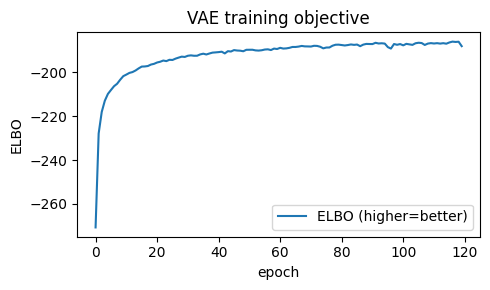

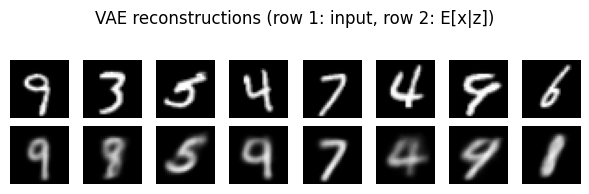

In [6]:
# Measurable claim: training increases the ELBO (our objective) monotonically-ish.
plt.figure(figsize=(5,3))
plt.plot(hist["elbo"], label="ELBO (higher=better)")
plt.xlabel("epoch"); plt.ylabel("ELBO"); plt.title("VAE training objective"); plt.legend()
plt.tight_layout(); plt.show()

# Reconstructions: top=input, bottom=reconstruction mean sigmoid(logits).
vae.eval()
with torch.no_grad():
    xb = Xflat[:8]
    logits, mu, logvar = vae(xb)
    recon = torch.sigmoid(logits)
pair = torch.cat([xb, recon], 0)
show_grid(pair, nrow=8, title="VAE reconstructions (row 1: input, row 2: E[x|z])", figsize=(6,2))

### 1.3 Making "KL regularization" *visible*

Textbooks say the KL term "keeps latent space nice" and warns about "holes" (regions of the prior that the model never mapped real data to). With a 2D latent we can *see* both. We measure three things:

1. **Per-example posteriors** $q_\phi(z\mid x)$ — a scatter of $\mu_\phi(x)$ colored by class.
2. **Aggregated posterior** $q_\phi(z)=\frac1N\sum_x q_\phi(z\mid x)$ vs the prior $\mathcal N(0,I)$. The ELBO only regularizes each posterior *individually*; there is no guarantee the *aggregate* matches the prior. Mismatch ⇒ sampling from $p(z)$ lands in low-density regions.
3. **Holes**: decode a grid over latent space and overlay where the aggregated posterior actually has mass. Grid points far from that mass are "holes" — the prior samples them, but the model never trained there, so decodes are garbage/blurry.

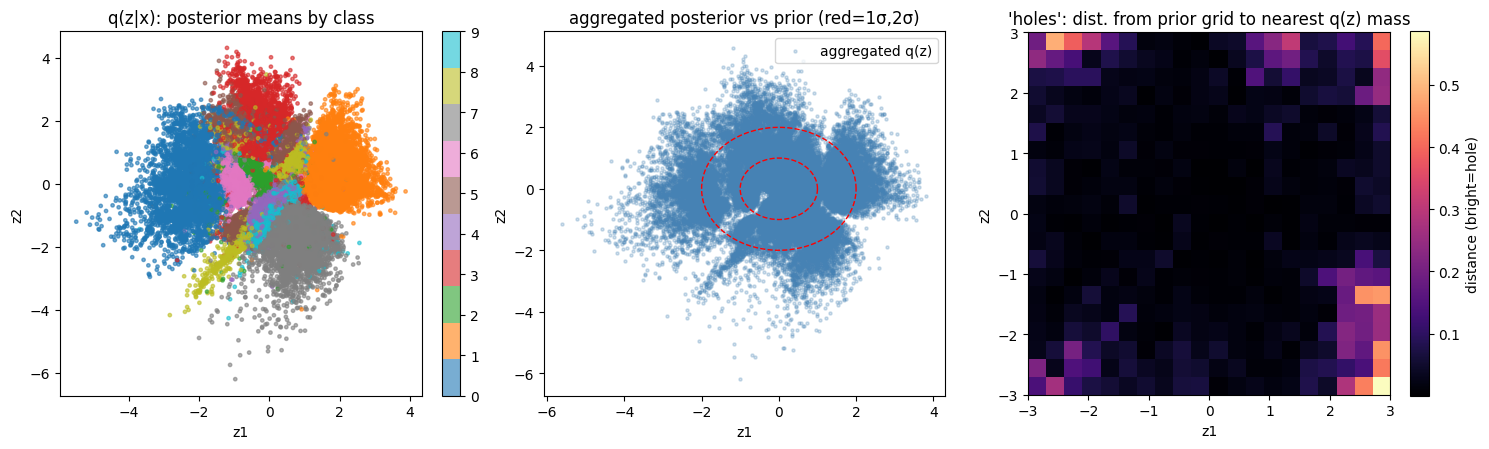

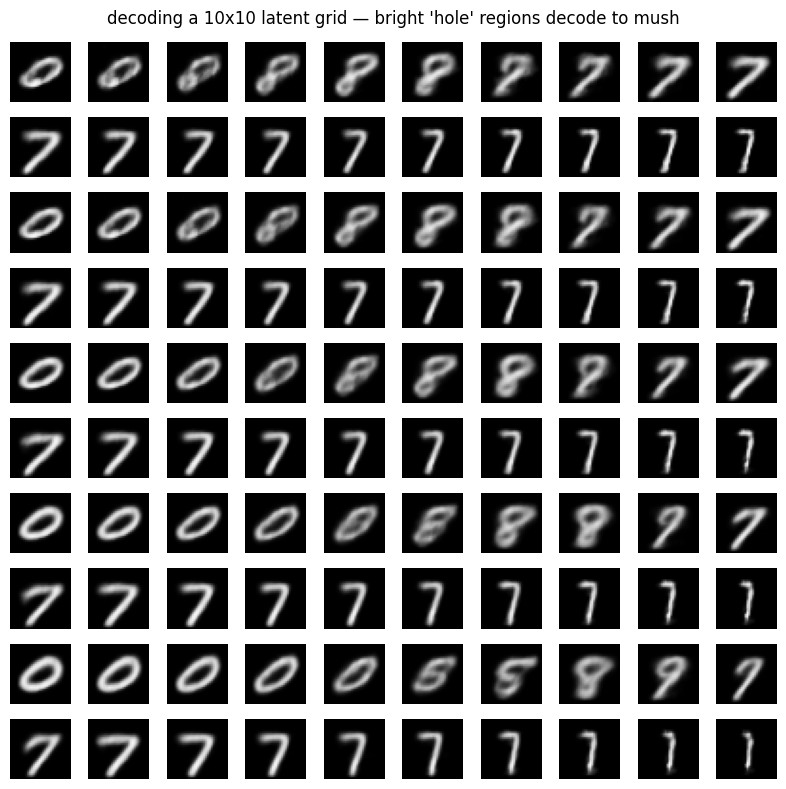

Fraction of prior grid points >0.5 from any real latent (holes): 0.0025


In [7]:
vae.eval()
with torch.no_grad():
    mu_all, logvar_all = vae.encode(Xflat)
    mu_np = mu_all.cpu().numpy(); y_np = y_all.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# (1) per-example posterior means, colored by class
sc = axes[0].scatter(mu_np[:,0], mu_np[:,1], c=y_np, cmap="tab10", s=6, alpha=0.6)
axes[0].set_title("q(z|x): posterior means by class"); axes[0].set_xlabel("z1"); axes[0].set_ylabel("z2")
plt.colorbar(sc, ax=axes[0], fraction=0.046)

# (2) aggregated posterior vs prior. Draw one z per example from q(z|x).
with torch.no_grad():
    z_agg = vae.reparam(mu_all, logvar_all).cpu().numpy()
axes[1].scatter(z_agg[:,0], z_agg[:,1], s=5, alpha=0.25, color="steelblue", label="aggregated q(z)")
th = np.linspace(0, 2*np.pi, 200)
for r in (1, 2):  # prior N(0,I): 1σ, 2σ circles
    axes[1].plot(r*np.cos(th), r*np.sin(th), "r--", lw=1)
axes[1].set_title("aggregated posterior vs prior (red=1σ,2σ)"); axes[1].set_xlabel("z1"); axes[1].set_ylabel("z2")
axes[1].legend(loc="upper right")

# (3) holes: decode a grid; shade grid cells that lie far from aggregated posterior mass.
g = 20; lim = 3.0
gx = np.linspace(-lim, lim, g); gy = np.linspace(-lim, lim, g)
from scipy.spatial import cKDTree
tree = cKDTree(z_agg)
GX, GY = np.meshgrid(gx, gy)
grid = np.stack([GX.ravel(), GY.ravel()], 1)
dist, _ = tree.query(grid, k=1)                     # distance to nearest real latent
dist = dist.reshape(g, g)
hm = axes[2].imshow(dist, extent=[-lim, lim, -lim, lim], origin="lower", cmap="magma")
axes[2].set_title("'holes': dist. from prior grid to nearest q(z) mass")
axes[2].set_xlabel("z1"); axes[2].set_ylabel("z2")
plt.colorbar(hm, ax=axes[2], fraction=0.046, label="distance (bright=hole)")
plt.tight_layout(); plt.show()

# Decode the same grid so the holes are also visually obvious.
with torch.no_grad():
    dec = torch.sigmoid(vae.decode(torch.tensor(grid, dtype=torch.float32, device=device)))
show_grid(dec.reshape(g*g, -1)[::1][:100], nrow=10,
          title="decoding a 10x10 latent grid — bright 'hole' regions decode to mush",
          figsize=(8,8))
print("Fraction of prior grid points >0.5 from any real latent (holes):",
      float((dist > 0.5).mean()))

### 1.4 The *exact* reason L2 (Gaussian) decoders blur

The usual claim "L2 loss causes blur" is a symptom, not a mechanism. Here is the mechanism, exactly.

If the decoder uses a Gaussian likelihood with fixed variance, $p_\theta(x\mid z)=\mathcal N\big(x;\, f_\theta(z),\,\sigma^2 I\big)$, then maximizing $\log p_\theta(x\mid z)$ is minimizing $\|x-f_\theta(z)\|^2$ — the L2 objective. The population minimizer of a squared error is a **conditional expectation**:

$$
f^\star(z)=\arg\min_f \ \mathbb E\big[\|x-f(z)\|^2\big] \;=\; \mathbb E[x\mid z].
$$

Now suppose a single code $z$ is consistent with **multiple** distinct plausible images (the true $p(x\mid z)$ is multimodal — e.g. a "4" that could be open- or closed-top). The optimal L2 decoder cannot output "either/or"; it must output the **average of the modes**, $\mathbb E[x\mid z]$, which is a blurry blend of both. Blur is not a numerical artifact — it is the *Bayes-optimal* output of a mean predictor under multimodal uncertainty.

We demonstrate this with a task where we know the ground truth is bimodal, so the blame is unambiguous.

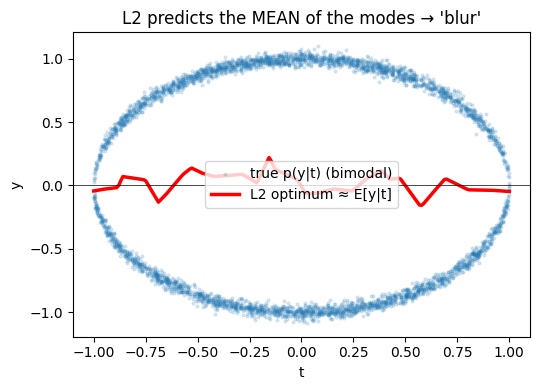

mean |prediction| (dist to mode-average line y=0): 0.061
mean dist from prediction to a real mode:          0.765
The fit hugs the between-modes average, not either mode -> that is the blur, exactly.


In [8]:
# Ground-truth conditional is bimodal: for input t in [-1,1], target y = ±sqrt(1-t^2)
# (points on a circle). So E[y|t]=0 sits BETWEEN the two modes — exactly the "blur".
torch.manual_seed(0)
n = 4000
t = (torch.rand(n,1)*2 - 1)
sign = torch.where(torch.rand(n,1) < 0.5, -1.0, 1.0)
yb = sign * torch.sqrt(torch.clamp(1 - t**2, min=0)) + 0.03*torch.randn(n,1)

reg = nn.Sequential(nn.Linear(1,128), nn.ReLU(), nn.Linear(128,128), nn.ReLU(), nn.Linear(128,1))
o = torch.optim.Adam(reg.parameters(), lr=5e-3)
for _ in range(3000):
    pred = reg(t); loss = F.mse_loss(pred, yb)  # <-- L2 / Gaussian-mean objective
    o.zero_grad(); loss.backward(); o.step()

tt = torch.linspace(-1,1,200).unsqueeze(1)
with torch.no_grad(): pp = reg(tt)
plt.figure(figsize=(5.5,4))
plt.scatter(t.numpy(), yb.numpy(), s=4, alpha=0.15, label="true p(y|t) (bimodal)")
plt.plot(tt.numpy(), pp.numpy(), "r-", lw=2.5, label="L2 optimum ≈ E[y|t]")
plt.axhline(0, color="k", lw=0.5)
plt.title("L2 predicts the MEAN of the modes → 'blur'"); plt.xlabel("t"); plt.ylabel("y"); plt.legend()
plt.tight_layout(); plt.show()

# Quantify: the L2 fit sits near the average of the two modes (~0), not on the data manifold.
with torch.no_grad():
    dist_to_zero = pp.abs().mean().item()
    dist_to_manifold = (pp.squeeze() - torch.sqrt(torch.clamp(1-tt.squeeze()**2,min=0))).abs().mean().item()
print(f"mean |prediction| (dist to mode-average line y=0): {dist_to_zero:.3f}")
print(f"mean dist from prediction to a real mode:          {dist_to_manifold:.3f}")
print("The fit hugs the between-modes average, not either mode -> that is the blur, exactly.")

### 1.5 Escaping blur: a menu of fixes (and VQ-VAE)

Section 1.4 pinned blur on the **Gaussian-mean decoder**: when $p(x\mid z)$ is multimodal, the Bayes-optimal squared-error predictor outputs $\mathbb E[x\mid z]$ — a blend. That is the principled mechanism. (Our digit VAE already uses a Bernoulli pixel likelihood, which avoids the L2↔Gaussian equivalence, but small MLPs on low-res inputs can still look soft for capacity and posterior-hole reasons.)

**Common escape routes:**

| Fix | Idea | Trade-off |
|-----|------|-----------|
| **Different likelihood** | Bernoulli / discretized logistic instead of Gaussian L2 | Still averages if the decoder is effectively unimodal per $z$ |
| **GAN (Part 2)** | No explicit $p_\theta(x)$; discriminator rewards sharp, realistic samples | No density; mode collapse; we'll study this next |
| **$\beta$-VAE / less KL** | Weaken the $\mathcal N(0,I)$ prior pressure | Helps "holes" and oversmoothing from KL, not the multimodal-mean issue by itself |
| **VQ-VAE** | **Discrete** latents: encoder snaps $z$ to nearest codebook vector | No continuous Gaussian KL; decoder learns one map per code — *implemented below* |
| **Diffusion (Part 4)** | Score matching at many noise levels | Sharp samples possible, but many sampling steps |

**VQ-VAE** (van den Oord et al.) replaces $z\in\mathbb R^d$ with a **finite codebook** $\{e_k\}_{k=1}^K$. The encoder outputs $z_e$; we set $z_q = e_{k^\star}$ where $k^\star = \arg\min_k \|z_e - e_k\|$. Training uses a straight-through estimator on $z_q$ and a commitment loss — **no KL on a continuous latent**, so the standard "Gaussian posterior → blur" story does not apply in the same way.

**Caveat:** VQ-VAE does **not** ship with a simple generative prior like $\mathcal N(0,I)$. The original paper learns a separate autoregressive model over codes. Picking **uniform random** codebook indices is a common demo mistake — most entries are never used during training and decode to mush. Below we (i) compare **reconstructions** on the same inputs (the fair sharpness check), and (ii) sample codes from the **empirical marginal** $p(k)$ on training data.

We will look at **GANs** in Part 2.

VQ epoch  30 | loss  187.98 | recon  187.95 | vq  0.027
VQ epoch  60 | loss  185.05 | recon  185.02 | vq  0.029
VQ epoch  90 | loss  183.99 | recon  183.96 | vq  0.030
VQ epoch 120 | loss  183.51 | recon  183.48 | vq  0.030


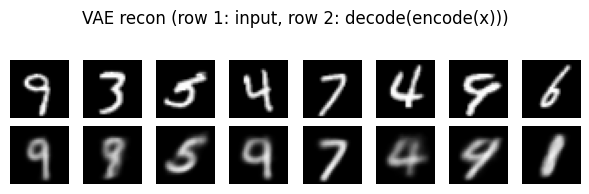

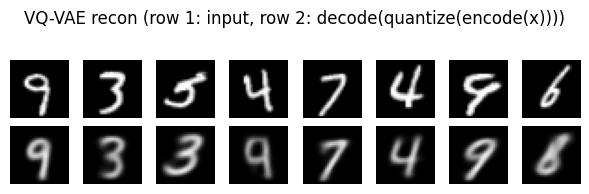

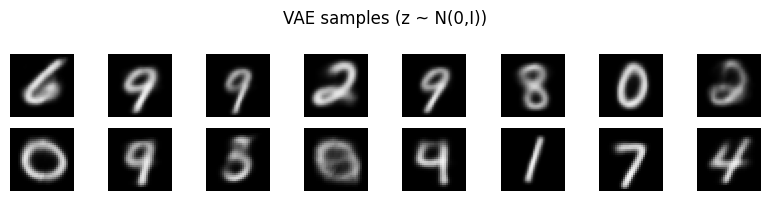

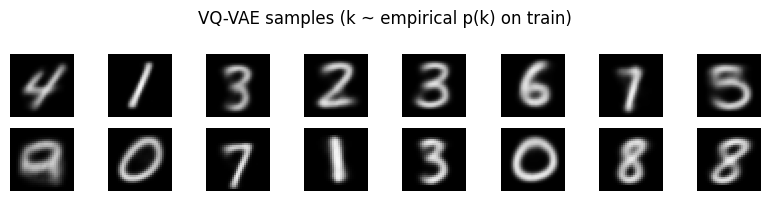

VQ-VAE used 236/256 codebook entries on training data.


In [11]:
class VectorQuantizer(nn.Module):
    """Nearest-neighbor lookup in a learned codebook (straight-through estimator)."""
    def __init__(self, num_embeddings, embedding_dim, beta=0.25):
        super().__init__()
        self.beta = beta
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        nn.init.normal_(self.embedding.weight, mean=0.0, std=1.0 / math.sqrt(embedding_dim))

    def forward(self, z):
        # z: (B, D)
        emb = self.embedding.weight
        dist = (z.pow(2).sum(1, keepdim=True)
                - 2 * z @ emb.t()
                + emb.pow(2).sum(1))
        idx = dist.argmin(1)
        z_q = self.embedding(idx)
        z_q_st = z + (z_q - z).detach()
        vq_loss = F.mse_loss(z_q, z.detach()) + self.beta * F.mse_loss(z_q.detach(), z)
        return z_q_st, vq_loss, idx


class VQVAE(nn.Module):
    def __init__(self, dim=DIM, embed_dim=16, num_embeddings=256, hidden=256):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, embed_dim))
        self.quant = VectorQuantizer(num_embeddings, embed_dim)
        self.dec = nn.Sequential(nn.Linear(embed_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, dim))

    def encode(self, x):
        return self.enc(x)

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        z_e = self.encode(x)
        z_e = F.normalize(z_e, p=2, dim=-1)
        z_q, vq_loss, idx = self.quant(z_e)
        return self.decode(z_q), vq_loss, idx


def vqvae_loss(logits, x, vq_loss):
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum(1).mean()
    return recon + vq_loss, recon, vq_loss

torch.manual_seed(SEED)
vqvae = VQVAE(embed_dim=16, num_embeddings=256).to(device)
opt_vq = torch.optim.Adam(vqvae.parameters(), lr=1e-3)
vq_epochs = epochs  # match VAE training budget
for ep in range(vq_epochs):
    idx = torch.randperm(len(Xflat))
    tot = [0.0, 0.0, 0.0]
    for i in range(0, len(Xflat), bs):
        xb = Xflat[idx[i:i+bs]]
        logits, vq_l, _ = vqvae(xb)
        loss, rec, vq = vqvae_loss(logits, xb, vq_l)
        opt_vq.zero_grad(); loss.backward(); opt_vq.step()
        tot[0] += loss.item() * len(xb); tot[1] += rec.item() * len(xb); tot[2] += vq.item() * len(xb)
    if (ep + 1) % max(1, vq_epochs // 4) == 0:
        n = len(Xflat); r = tot[1]/n/IMG/IMG; v = tot[2]/n
        print(f"VQ epoch {ep+1:3d} | recon {r:.4f}/px | vq {v:.4f} (latent MSE)")

# Fair comparison: reconstructions on the *same* inputs (encode -> decode).
vae.eval(); vqvae.eval()
xb = Xflat[:8]
with torch.no_grad():
    vae_rec = torch.sigmoid(vae(xb)[0])
    vq_rec = torch.sigmoid(vqvae(xb)[0])
show_grid(torch.cat([xb, vae_rec], 0), nrow=8,
          title="VAE recon (row 1: input, row 2: decode(encode(x)))", figsize=(6, 2))
show_grid(torch.cat([xb, vq_rec], 0), nrow=8,
          title="VQ-VAE recon (row 1: input, row 2: decode(quantize(encode(x))))", figsize=(6, 2))

# Generation: VAE z ~ N(0,I); VQ-VAE sample k from empirical p(k) on training data.
with torch.no_grad():
    vae_samp = torch.sigmoid(vae.decode(torch.randn(16, 2, device=device)))
    _, _, codes = vqvae(Xflat)
    K = vqvae.quant.embedding.num_embeddings
    hist_codes = torch.bincount(codes, minlength=K).float()
    probs = hist_codes / hist_codes.sum()
    idx = torch.multinomial(probs, 16, replacement=True)
    vq_samp = torch.sigmoid(vqvae.decode(vqvae.quant.embedding(idx)))

show_grid(vae_samp, nrow=8, title="VAE samples (z ~ N(0,I))", figsize=(8, 2))
show_grid(vq_samp, nrow=8, title="VQ-VAE samples (k ~ empirical p(k) on train)", figsize=(8, 2))
used = (hist_codes > 0).sum().item()
print(f"VQ-VAE used {used}/{K} codebook entries on training data.")

### 1.6 The conv upgrade: spatial latents beat flat MLPs

The linear VQ-VAE above proves the **discrete-latent** idea: once the codebook is initialized at the right scale and actually used, blur from continuous Gaussian averaging largely disappears. The remaining soft edges are mostly a **topology** issue — `nn.Linear` on flattened pixels has no notion of locality.

A **convolutional VQ-VAE** keeps the same `VectorQuantizer`, but the encoder produces a **spatial** latent map $(B, C, H, W)$. Each $H \times W$ location snaps to its own codebook entry, so the decoder can mix local stroke fragments instead of memorizing whole images in one vector. This is the architecture used in the original VQ-VAE paper and in systems like VQ-GAN.

Below we train a minimal `Conv2d` / `ConvTranspose2d` variant on the same data and compare reconstructions to the flat MLP VQ-VAE.

In [ ]:
class ConvVQVAE(nn.Module):
    """VQ-VAE with a spatial latent map: each latent cell covers a patch of the image."""
    def __init__(self, embed_dim=64, num_embeddings=256, hidden=64):
        super().__init__()
        self.embed_dim = embed_dim
        self.enc = nn.Sequential(
            nn.Conv2d(1, hidden, 4, 2, 1), nn.ReLU(),      # 32→16
            nn.Conv2d(hidden, hidden, 4, 2, 1), nn.ReLU(), # 16→8
            nn.Conv2d(hidden, embed_dim, 3, 1, 1),
        )
        self.quant = VectorQuantizer(num_embeddings, embed_dim)
        self.dec = nn.Sequential(
            nn.Conv2d(embed_dim, hidden, 3, 1, 1), nn.ReLU(),
            nn.ConvTranspose2d(hidden, hidden, 4, 2, 1), nn.ReLU(),  # 8→16
            nn.ConvTranspose2d(hidden, 1, 4, 2, 1),                   # 16→32
        )

    def _quantize_spatial(self, z):
        B, C, H, W = z.shape
        z_flat = F.normalize(z.permute(0, 2, 3, 1).reshape(-1, C), p=2, dim=-1)
        z_q, vq_loss, idx = self.quant(z_flat)
        z_q = z_q.reshape(B, H, W, C).permute(0, 3, 1, 2)
        return z_q, vq_loss, idx

    def forward(self, x):
        z_q, vq_loss, idx = self._quantize_spatial(self.enc(x))
        return self.dec(z_q), vq_loss, idx


def conv_vqvae_loss(logits, x, vq_loss):
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum((1, 2, 3)).mean()
    return recon + vq_loss, recon, vq_loss

torch.manual_seed(SEED)
conv_vqvae = ConvVQVAE(embed_dim=64, num_embeddings=256).to(device)
opt_conv = torch.optim.Adam(conv_vqvae.parameters(), lr=1e-3)
conv_epochs = max(20, vq_epochs // 2) if QUICK else vq_epochs
for ep in range(conv_epochs):
    idx = torch.randperm(len(X_all))
    tot = [0.0, 0.0, 0.0]
    for i in range(0, len(X_all), bs):
        xb = X_all[idx[i:i+bs]]
        logits, vq_l, _ = conv_vqvae(xb)
        loss, rec, vq = conv_vqvae_loss(logits, xb, vq_l)
        opt_conv.zero_grad(); loss.backward(); opt_conv.step()
        tot[0] += loss.item() * len(xb); tot[1] += rec.item() * len(xb); tot[2] += vq.item() * len(xb)
    if (ep + 1) % max(1, conv_epochs // 4) == 0:
        n = len(X_all); r = tot[1]/n/IMG/IMG; v = tot[2]/n
        print(f"Conv VQ epoch {ep+1:3d} | recon {r:.4f}/px | vq {v:.4f} (latent MSE)")

# Side-by-side reconstructions: flat MLP VQ-VAE vs conv VQ-VAE (same inputs).
vqvae.eval(); conv_vqvae.eval()
xb_img = X_all[:8]
with torch.no_grad():
    mlp_rec = torch.sigmoid(vqvae(xb_img.reshape(8, -1))[0]).reshape_as(xb_img)
    conv_rec = torch.sigmoid(conv_vqvae(xb_img)[0])
show_grid(torch.cat([xb_img, mlp_rec], 0), nrow=8,
          title="Flat VQ-VAE recon (row 1: input, row 2: recon)", figsize=(6, 2))
show_grid(torch.cat([xb_img, conv_rec], 0), nrow=8,
          title="Conv VQ-VAE recon (row 1: input, row 2: recon)", figsize=(6, 2))

# # Generation: sample a full 8×8 latent grid of codes from the training marginal.
# with torch.no_grad():
#     _, _, codes = conv_vqvae(X_all)
#     K = conv_vqvae.quant.embedding.num_embeddings
#     hist_codes = torch.bincount(codes, minlength=K).float()
#     probs = hist_codes / hist_codes.sum()
#     H = W = IMG // 4
#     n_samp = 16
#     idx = torch.multinomial(probs, n_samp * H * W, replacement=True)
#     z_q = conv_vqvae.quant.embedding(idx).reshape(n_samp, H, W, conv_vqvae.embed_dim).permute(0, 3, 1, 2)
#     conv_samp = torch.sigmoid(conv_vqvae.dec(z_q))
# show_grid(conv_samp, nrow=8, title="Conv VQ-VAE samples (spatial grid, k ~ empirical p(k))", figsize=(8, 2))
# used_conv = (hist_codes > 0).sum().item()
# print(f"Conv VQ-VAE used {used_conv}/{K} codebook entries across all spatial positions on training data.")